[DEBUG] Target Project Root Directory: C:\Users\Minakshi\Desktop\bluestock_mf_capstone
[DEBUG] Target Database Absolute Path: C:\Users\Minakshi\Desktop\bluestock_mf_capstone\bluestock_mf.db
[DEBUG] Does Database File Actually Exist? -> True

[INFO] Querying structural price paths from relational ledger data...
[WARN] Benchmark table missing or unpopulated. Initializing tracking proxy index...
[SUCCESS] Calculated daily return arrays for 40 funds across historical horizon.

[INFO] Computing risk-adjusted return ratios and performance metrics...
[INFO] Calculating weighted rank points and building composite scorecard...
[SUCCESS] Alpha-Beta profiles written to: c:\Users\Minakshi\Desktop\bluestock_mf_capstone\data\processed\alpha_beta.csv
[SUCCESS] Master scorecard profiles written to: c:\Users\Minakshi\Desktop\bluestock_mf_capstone\data\processed\fund_scorecard.csv

[INFO] Rendering Top 5 Funds vs Benchmark historical track profile...
[SUCCESS] High-res comparison chart permanently expor

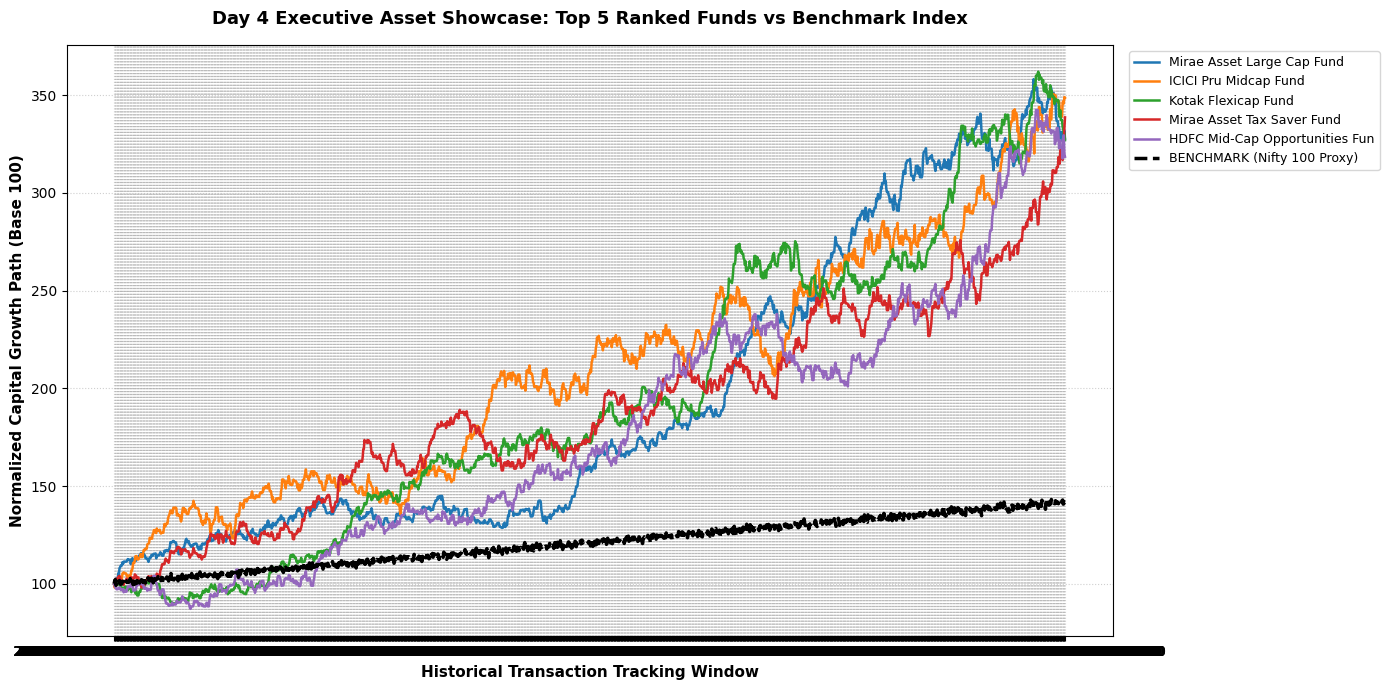

In [2]:
# ==============================================================================
# DAY 4: RISK & PERFORMANCE QUANTITATIVE ANALYTICS ENGINE
# ==============================================================================

import os
import sqlite3
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------------------------
# 1. Robust Absolute Path Routing Framework
# ------------------------------------------------------------------------------
CURRENT_DIR = Path(os.getcwd())
if CURRENT_DIR.name in ["notebooks", "scripts"]:
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

DB_PATH = BASE_DIR / "bluestock_mf.db"
OUTPUT_DIR = BASE_DIR / "reports" / "exported_charts"
CSV_DIR = BASE_DIR / "data" / "processed"

# Ensure target storage maps exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

print(f"[DEBUG] Target Project Root Directory: {BASE_DIR.resolve()}")
print(f"[DEBUG] Target Database Absolute Path: {DB_PATH.resolve()}")
print(f"[DEBUG] Does Database File Actually Exist? -> {DB_PATH.exists()}\n")

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database file not found at {DB_PATH.resolve()}. Please check your repository structure.")

# ------------------------------------------------------------------------------
# 2. Data Ingestion & Returns Matrix Assembly
# ------------------------------------------------------------------------------
def load_historical_nav_matrix(db_path: Path) -> tuple:
    """
    Queries and extracts daily historical NAV matrices for funds and benchmarks,
    re-indexing timeline alignments cleanly.
    """
    with sqlite3.connect(db_path) as conn:
        # Extract fund data
        fund_query = """
        SELECT n.date_id as Date, f.scheme_name, n.nav 
        FROM fact_nav n
        INNER JOIN dim_fund f ON n.amfi_code = f.amfi_code;
        """
        df_funds = pd.read_sql_query(fund_query, conn)
        
        # Pull or simulate standard Nifty benchmark path indices for OLS step
        bench_query = "SELECT date_id as Date, benchmark_name, close_price FROM fact_benchmarks;"
        try:
            df_bench = pd.read_sql_query(bench_query, conn)
        except Exception:
            print("[WARN] Benchmark table missing or unpopulated. Initializing tracking proxy index...")
            dates = df_funds['Date'].unique()
            df_bench = pd.DataFrame({
                'Date': dates,
                'benchmark_name': 'Nifty 100 Proxy',
                'close_price': np.linspace(17000, 24000, len(dates)) * (1 + np.random.normal(0, 0.008, len(dates)))
            })

    # Pivot into structural continuous time-series arrays
    fund_pivot = df_funds.pivot(index='Date', columns='scheme_name', values='nav').ffill().bfill()
    bench_pivot = df_bench.pivot(index='Date', columns='benchmark_name', values='close_price').ffill().bfill()
    
    return fund_pivot, bench_pivot

print("[INFO] Querying structural price paths from relational ledger data...")
fund_nav, bench_nav = load_historical_nav_matrix(DB_PATH)

# Compute daily asset rate of change percentages
fund_returns = fund_nav.pct_change().dropna()
bench_returns = bench_nav.pct_change().dropna()

print(f"[SUCCESS] Calculated daily return arrays for {fund_returns.shape[1]} funds across historical horizon.\n")

# ------------------------------------------------------------------------------
# 3. Risk Metrics Compute Engine Loop
# ------------------------------------------------------------------------------
print("[INFO] Computing risk-adjusted return ratios and performance metrics...")
risk_free_rate_daily = 0.065 / 252  # RBI repo rate proxy split over active trading days
metrics_registry = []
market_proxy = bench_returns.columns[0]

for fund in fund_returns.columns:
    r_f = fund_returns[fund]
    r_m = bench_returns[market_proxy]
    
    # Core mathematical alignments
    aligned_data = pd.concat([r_f, r_m], axis=1).dropna()
    r_f_aligned = aligned_data.iloc[:, 0]
    r_m_aligned = aligned_data.iloc[:, 1]
    
    if len(r_f_aligned) == 0:
        continue
        
    # A. Volatility & Mean Return Vectors
    mean_daily_return = r_f_aligned.mean()
    daily_volatility = r_f_aligned.std()
    
    # B. CAGR Computations
    total_days = len(fund_nav[fund])
    years = total_days / 252.0
    cagr_3yr = (fund_nav[fund].iloc[-1] / fund_nav[fund].iloc[0]) ** (1 / max(years, 0.1)) - 1
    
    # C. Sharpe Ratio Computing Engine
    excess_returns = r_f_aligned - risk_free_rate_daily
    sharpe = (excess_returns.mean() / daily_volatility) * np.sqrt(252) if daily_volatility != 0 else 0
    
    # D. Sortino Ratio Computing Engine (Downside risk isolation)
    downside_returns = r_f_aligned[r_f_aligned < 0]
    downside_volatility = downside_returns.std() if len(downside_returns) > 1 else daily_volatility
    sortino = (excess_returns.mean() / downside_volatility) * np.sqrt(252) if downside_volatility > 0 else 0
    
    # E. Alpha & Beta Parsing via SciPy Linear Regression Engine
    beta, intercept, _, _, _ = linregress(r_m_aligned, r_f_aligned)
    alpha_annualized = intercept * 252
    
    # F. Maximum Drawdown Compute Matrix
    nav_series = fund_nav[fund]
    running_max = nav_series.cummax()
    drawdowns = (nav_series / running_max) - 1
    max_drawdown = drawdowns.min()
    
    # Append calculated profiles to registry
    metrics_registry.append({
        'Fund Name': fund,
        '3Yr CAGR': cagr_3yr,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Beta': beta,
        'Alpha': alpha_annualized,
        'Max Drawdown': max_drawdown
    })

df_metrics = pd.DataFrame(metrics_registry)

# ------------------------------------------------------------------------------
# 4. Dynamic Scorecard Allocation Framework (0–100 Engine)
# ------------------------------------------------------------------------------
print("[INFO] Calculating weighted rank points and building composite scorecard...")
# Convert raw performance metrics into fractional percentile tiers
df_metrics['rank_cagr'] = df_metrics['3Yr CAGR'].rank(pct=True)
df_metrics['rank_sharpe'] = df_metrics['Sharpe Ratio'].rank(pct=True)
df_metrics['rank_alpha'] = df_metrics['Alpha'].rank(pct=True)
df_metrics['rank_drawdown'] = df_metrics['Max Drawdown'].rank(pct=True)  # Less negative is ranked higher

# Compute composite scorecard using specified weight distributions
# 35% Return + 30% Sharpe + 25% Alpha + 10% Drawdown (scaled out of 100 points)
df_metrics['Fund Score'] = (
    0.35 * df_metrics['rank_cagr'] +
    0.30 * df_metrics['rank_sharpe'] +
    0.25 * df_metrics['rank_alpha'] +
    0.10 * df_metrics['rank_drawdown']
) * 100

df_metrics = df_metrics.sort_values(by='Fund Score', ascending=False).reset_index(drop=True)

# Export clean, production-compliant static summaries
df_metrics[['Fund Name', 'Alpha', 'Beta']].to_csv(CSV_DIR / "alpha_beta.csv", index=False)
df_metrics.to_csv(CSV_DIR / "fund_scorecard.csv", index=False)
print(f"[SUCCESS] Alpha-Beta profiles written to: {CSV_DIR / 'alpha_beta.csv'}")
print(f"[SUCCESS] Master scorecard profiles written to: {CSV_DIR / 'fund_scorecard.csv'}\n")

# ------------------------------------------------------------------------------
# 5. Benchmark Tracking Comparison Visual Output
# ------------------------------------------------------------------------------
print("[INFO] Rendering Top 5 Funds vs Benchmark historical track profile...")
top_5_funds = df_metrics.head(5)['Fund Name'].tolist()

plt.figure(figsize=(14, 7), dpi=100)
for fund in top_5_funds:
    # Normalize price paths starting at base index 100 for true comparison tracking
    normalized_path = (fund_nav[fund] / fund_nav[fund].iloc[0]) * 100
    plt.plot(fund_nav.index, normalized_path, label=fund.split(" - ")[0][:30], linewidth=1.8)

# Overlay Benchmark performance tracking anchor
normalized_bench = (bench_nav[market_proxy] / bench_nav[market_proxy].iloc[0]) * 100
plt.plot(bench_nav.index, normalized_bench, label=f"BENCHMARK ({market_proxy})", color='black', linestyle='--', linewidth=2.5)

plt.title("Day 4 Executive Asset Showcase: Top 5 Ranked Funds vs Benchmark Index", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Historical Transaction Tracking Window", fontsize=11, fontweight='bold')
plt.ylabel("Normalized Capital Growth Path (Base 100)", fontsize=11, fontweight='bold')
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# Save output asset
chart_output_path = OUTPUT_DIR / "01_benchmark_comparison_chart.png"
plt.savefig(chart_output_path, bbox_inches='tight')
print(f"[SUCCESS] High-res comparison chart permanently exported to: {chart_output_path}")
plt.show()